In [52]:
import pandas as pd
import numpy as np

In [53]:
df = pd.read_parquet('data/bitcoin_tweet.parquet')

### Data Analysis

In [54]:
df.describe()

,user_followers,user_friends,account_age_days,url_count
count,632179.0,632179.0,632179.000000,632179.000000
mean,4223.438121,768.950281,2555.759374,0.000321
std,53956.704763,2686.274589,1558.663658,0.017917
min,0.0,0.0,786.000000,0.000000
25%,40.0,93.0,1359.000000,0.000000
50%,163.0,270.0,1769.000000,0.000000
75%,786.0,742.0,3721.000000,0.000000
max,8076992.0,656204.0,6924.000000,1.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 632179 entries, 16 to 4595426
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   user_name         632179 non-null  object             
 1   user_created      632179 non-null  datetime64[us, UTC]
 2   user_followers    632179 non-null  Int64              
 3   user_friends      632179 non-null  Int64              
 4   user_verified     632179 non-null  boolean            
 5   date              632179 non-null  datetime64[us, UTC]
 6   text              632179 non-null  object             
 7   hashtags          632178 non-null  object             
 8   mentions          632179 non-null  object             
 9   account_age_days  632179 non-null  int64              
 10  age_bucket        632179 non-null  category           
 11  url_count         632179 non-null  int64              
 12  text_clean        632179 non-null  object      

### Numerical column analysis

In [56]:
numerical_columns = df.select_dtypes(include=['int64', 'Int64']).columns.tolist()

In [57]:
df[numerical_columns].describe().loc[['min', 'max']].T

,min,max
user_followers,0.0,8076992.0
user_friends,0.0,656204.0
account_age_days,786.0,6924.0
url_count,0.0,1.0


- `account_age_days` has been pre processed (filtered by account age date to remove the new accounts) 
- `url_count` is engineered column that is grabbed from the text column (it has been capped at 1 to remove the **spam, ad** tweets)

#### Categorical column analysis

In [58]:
cat_columns = df.select_dtypes(include=['category', 'object']).columns.tolist()
cat_columns.remove('text')
cat_columns.remove('text_clean') # will analyse it later
cat_columns

['user_name', 'hashtags', 'mentions', 'age_bucket']

In [59]:
df.hashtags.str[0]

16             BTC
24             BTC
25             BTC
31         Bitcoin
51          cronje
            ...   
4595407       fiat
4595411    Bitcoin
4595422    bitcoin
4595425     Solana
4595426    Bitcoin
Name: hashtags, Length: 632179, dtype: object

In [60]:
df.age_bucket.value_counts()

age_bucket
3-5 yr     279370
>10 yr     162001
5-10 yr    144117
2-3 yr      46691
<2 yr           0
Name: count, dtype: int64

`account_age` with less than **2 years** has been removed during date pre-processing

### `hashtags` Analysis

In [61]:
hashtags_exploded = df['hashtags'].explode().reset_index(drop=True)
hashtag_counts = hashtags_exploded.str.lower().value_counts().reset_index()

print(f'total unique hashtags: {len(hashtag_counts):,}')

more_than_once = hashtag_counts[hashtag_counts['count'] > 1]
print(f'Total unique hashtags that have appeared more than once: {len(more_than_once):,}')
print("\nTop hashtags appearing more than once:")
hashtag_counts.head()

total unique hashtags: 34,164
Total unique hashtags that have appeared more than once: 12,020

Top hashtags appearing more than once:


,hashtags,count
0,bitcoin,465471
1,btc,233680
2,crypto,51301
3,eth,27724
4,ethereum,20270


From ~600k tweets there are 34k unique hashtags found

### `user_name` Analysis

In [62]:
username_counts_df = df.user_name.value_counts()
username_counts_df.head(5)

user_name
Herry Mason                    99
Asher V.                       98
Crypto Advisor                 96
crypto spot                    95
500 headlines about bitcoin    94
Name: count, dtype: int64

During the pre processing we have removed accounts with **more than 100 tweets** (Bot account tweet, daily price news bot tweet)

In [63]:
for text in df[df.user_name == '500 headlines about bitcoin']['text'].head():
    print(text)

You might not see the need for money that can’t be counterfeited. But 1.4 billion Indians do. #bitcoin
The system is rigged. So we’re building one that can’t be. #bitcoin
Make your last overdraft your last. #bitcoin
Feel the rush of finally getting to agree with Marc Andreessen. #bitcoin
There’s no such thing as a blood bitcoin. #bitcoin


Some of the account with high tweet counts still seem to a bot account but we cannot remove the account with tweet volume cap

In [64]:
print(f"number of unique users: {df.user_name.nunique():,}")
print(df.user_name.value_counts().describe().loc[['min', '75%', 'max']].to_frame().T)

number of unique users: 227,205
       min  75%   max
count  1.0  2.0  99.0


most of the users (75%) only tweeted twice

In [65]:
print(f"95th percentile of users tweeted {df.user_name.value_counts().quantile(0.95)} times")

95th percentile of users tweeted 10.0 times


In [66]:
for text in df[df.user_name.isin(username_counts_df[username_counts_df == 2].index)]['text'].head(5):
    print(text)

@iamDonaldYusuf @yuzomausman @aproko_doctor Not now as there is fud of sub $30k #BTC ...people no wan risk buy at dz prices imo
Move Digital Energy Through Cyber Space. #Bitcoin #BTC
@MWCunfiltered If we went to 25K-27K rallied to 32k and chopped down back again that would be awful if you’re holding.  But maybe alts destroyed and #BTC at such an attractive price is what’s needed
Somebody please take #BTC behind the shed and put it out of its misery.
@TTGMaverick I will examine your theory of being highs on Wednesday. Unfortunately, #btc is now coincide with the movement of #SPX.


most of them are **replied** or **mentioned** someone of their tweet. which is great for **social graph** also this means **all human/non-bot** tweets which is great for sentiment analysis

#### `Mentions` exploration

In [67]:
mentions_exploded = df.mentions.explode()

In [68]:
mentions_exploded.value_counts().head()

mentions
elonmusk           11821
saylor              9472
peterschiff         7564
cz_binance          4817
bitcoinmagazine     4743
Name: count, dtype: int64

there are 2 people mentioned the most (other than elonmusk). might be useful for social graph

In [69]:
for text in df[(df.user_name =='saylor')]['text'].head():
    print(text)

i told you all yesterday to buy the #Bitcoin  dip

did you do it?

probably not... 

BUT there is still hope for you

you can still mortgage your house and buy bitcoin

you can still sell your clothes and buy bitcoin

you can still live on the poverty line... and buy bitcoin
@smolleader @smolEggOpinion this is the correct way of going about it, if you have anything else left to sell I suggest doing that and buying more #Bitcoin
they say that smols have topped

they said the same thing about #Bitcoin in 2011, 2013 and 2017 

i think im noticing a pattern here
i really think a16z should just buy #bitcoin with leverage and just send it
looking for a job after the events of today if anyone needs a good boat captain im available to steer the ship #Bitcoin


He seems to be very active in twitter in bitcoin community

**peterschiff** (american stockbroker) and **elon musk** and the other 2 did not appear in the clean or the initial dataset\
so `saylor` is probably the most popular/communicative one in bitcoin community

# Network Building

### `hashtag` co-occurrence network

In [70]:
from itertools import combinations
from collections import Counter
import ast

# parse hashtags column into actual lists
# hashtags may come back from parquet as numpy arrays, Python lists, or strings
def parse_hashtags(h):
    if isinstance(h, str):
        try:
            h = ast.literal_eval(h)
        except:
            return []
    try:
        return [str(tag).lower().strip() for tag in h]
    except:
        return []

df['hashtag_list'] = df['hashtags'].apply(parse_hashtags)

# Only keep tweets with 2+ hashtags (need at least 2 to form an edge)
df_net = df[df['hashtag_list'].apply(len) >= 2]
print(f"Tweets with 2+ hashtags: {len(df_net):,}")

# Count co-occurrences
co_occurrences = Counter()
for tags in df_net['hashtag_list']:
    for pair in combinations(sorted(set(tags)), 2):
        co_occurrences[pair] += 1

print(f"Unique pairs found: {len(co_occurrences)}")
print("Top 10 pairs:", co_occurrences.most_common(10))

Tweets with 2+ hashtags: 280,338
Unique pairs found: 145426
Top 10 pairs: [(('bitcoin', 'btc'), 49190), (('bitcoin', 'crypto'), 34730), (('btc', 'crypto'), 23832), (('btc', 'eth'), 22042), (('bitcoin', 'ethereum'), 16122), (('bitcoin', 'cryptocurrency'), 15243), (('btc', 'cryptocurrency'), 9393), (('bitcoin', 'eth'), 8126), (('bnb', 'btc'), 7004), (('btc', 'ethereum'), 5837)]


#### Check distribution


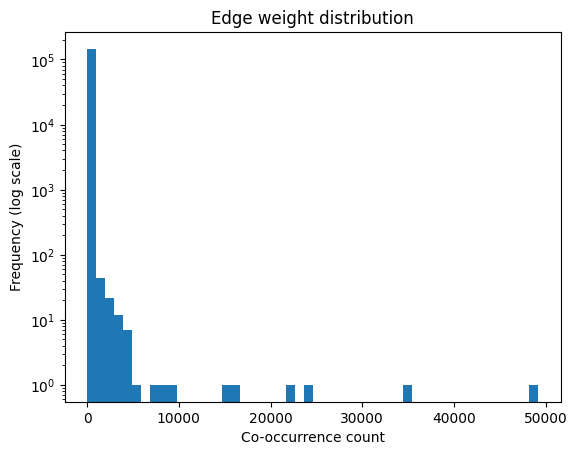

In [71]:
import matplotlib.pyplot as plt

weights = list(co_occurrences.values()) # count of co occurences
plt.hist(weights, bins=50, log=True)
plt.xlabel('Co-occurrence count')
plt.ylabel('Frequency (log scale)')
plt.title('Edge weight distribution')
plt.show()

MIN_WEIGHT = 50  # pairs that co-occurred at least 50 times

In [72]:
import networkx as nx

G = nx.Graph() # initilaize graph
for (tag1, tag2), weight in co_occurrences.items():
    if weight >= MIN_WEIGHT:
        G.add_edge(tag1, tag2, weight=weight)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Is connected: {nx.is_connected(G)}")

# Largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()
print(f"Largest component nodes: {G_main.number_of_nodes()}")
print(f"Average clustering coefficient: {nx.average_clustering(G_main):.4f}")
print(f"Average shortest path length: {nx.average_shortest_path_length(G_main):.4f}")

Nodes: 612
Edges: 1634
Density: 0.0087
Is connected: False
Largest component nodes: 605
Average clustering coefficient: 0.6309
Average shortest path length: 2.1375


In [73]:
# Degree centrality: how many connections does each hashtag have
degree_cent = nx.degree_centrality(G_main)

# Betweenness centrality: which hashtags bridge different communities
between_cent = nx.betweenness_centrality(G_main, weight='weight')

# PageRank: based on incooming links
pagerank = nx.pagerank(G_main, weight='weight')

# Weighted degree (strength): total weight of all connections
strength = dict(G_main.degree(weight='weight'))

centrality_df = pd.DataFrame({
    'hashtag': list(degree_cent.keys()),
    'degree_centrality': list(degree_cent.values()),
    'betweenness_centrality': [between_cent[n] for n in degree_cent.keys()],
    'pagerank': [pagerank[n] for n in degree_cent.keys()],
    'strength': [strength[n] for n in degree_cent.keys()]
}).sort_values('pagerank', ascending=False)

centrality_df.head(20)

,hashtag,degree_centrality,betweenness_centrality,pagerank,strength
0,bitcoin,0.834437,0.596391,0.219167,282916
1,btc,0.632450,0.435058,0.160616,228981
2,crypto,0.223510,0.070443,0.067029,107424
20,eth,0.132450,0.038255,0.033749,55829
34,cryptocurrency,0.109272,0.033653,0.027076,43856
58,ethereum,0.110927,0.032394,0.025847,41921
39,bnb,0.091060,0.035554,0.015409,23987
31,bsc,0.071192,0.013925,0.012041,17602
55,binance,0.066225,0.019943,0.010617,16847
11,blockchain,0.052980,0.008066,0.008151,12390


## Detect communities

In [74]:
from community import community_louvain

partition = community_louvain.best_partition(G_main, weight='weight')
df_partition = pd.DataFrame(partition.items(), columns=['Node', 'Community'])

df_partition.groupby('Community')['Node'].unique()

Community
0                   [releasethekraken, lmoon, longmoon]
1     [btc, 11minutes, wct, klv, signals, sol, alt, ...
2                     [lep100token, litho, lithosphere]
3     [bitcoin, crypto, stocks, cryptocurrencynews, ...
4     [bsc, nft, binance, defi, nftart, nfts, memeco...
5                     [fegtoken, feg, fegex, smartdefi]
6            [coinbase, polyswarm, bep2, hack, hacking]
7                           [eum, eumwallet, walleteum]
8                                [helios, pnp, pnpcoin]
9                                          [ecash, xec]
10                       [transhumancoin, charity, thc]
11                            [staking, betfurysuccess]
12                          [robinhood, nint, nintcoin]
13                                           [amc, gme]
14                               [algotrade, stewiebot]
15                                  [tokenomics, shibk]
16                                     [ravencoin, rvn]
17                               [bita

**21 communities** found

#### Rank the nodes within each community using a pagerank dictionary.
- it shows the `10 most influential` hashtags in each community

In [75]:
from collections import defaultdict

# Add community label to each node
nx.set_node_attributes(G_main, partition, 'community')

communities = defaultdict(list)
for node, comm_id in partition.items():
    communities[comm_id].append(node)

# Print top hashtags per community
for comm_id, members in sorted(communities.items()):
    
    # Sort members by pagerank within community
    members_sorted = sorted(members, key=lambda x: pagerank.get(x, 0), reverse=True)
    print(f"\nCommunity {comm_id} ({len(members)} hashtags):")
    print("  Top hashtags:", members_sorted[:10])


Community 0 (3 hashtags):
  Top hashtags: ['lmoon', 'releasethekraken', 'longmoon']

Community 1 (213 hashtags):
  Top hashtags: ['btc', 'eth', 'bnb', 'cryptomining', 'seasonaltokens', 'xrp', 'doge', 'cyclicalinvesting', 'ada', 'shib']

Community 2 (3 hashtags):
  Top hashtags: ['litho', 'lep100token', 'lithosphere']

Community 3 (291 hashtags):
  Top hashtags: ['bitcoin', 'crypto', 'cryptocurrency', 'ethereum', 'blockchain', 'dogecoin', 'cryptocrash', 'cryptocurrencies', 'altcoins', 'hodl']

Community 4 (51 hashtags):
  Top hashtags: ['bsc', 'binance', 'nft', 'defi', 'nfts', 'binancesmartchain', 'ftx', 'ikonic', 'nftcommunity', 'legitcommunity']

Community 5 (4 hashtags):
  Top hashtags: ['feg', 'fegex', 'fegtoken', 'smartdefi']

Community 6 (5 hashtags):
  Top hashtags: ['coinbase', 'hacking', 'hack', 'bep2', 'polyswarm']

Community 7 (3 hashtags):
  Top hashtags: ['eum', 'eumwallet', 'walleteum']

Community 8 (3 hashtags):
  Top hashtags: ['pnpcoin', 'helios', 'pnp']

Community 9 (

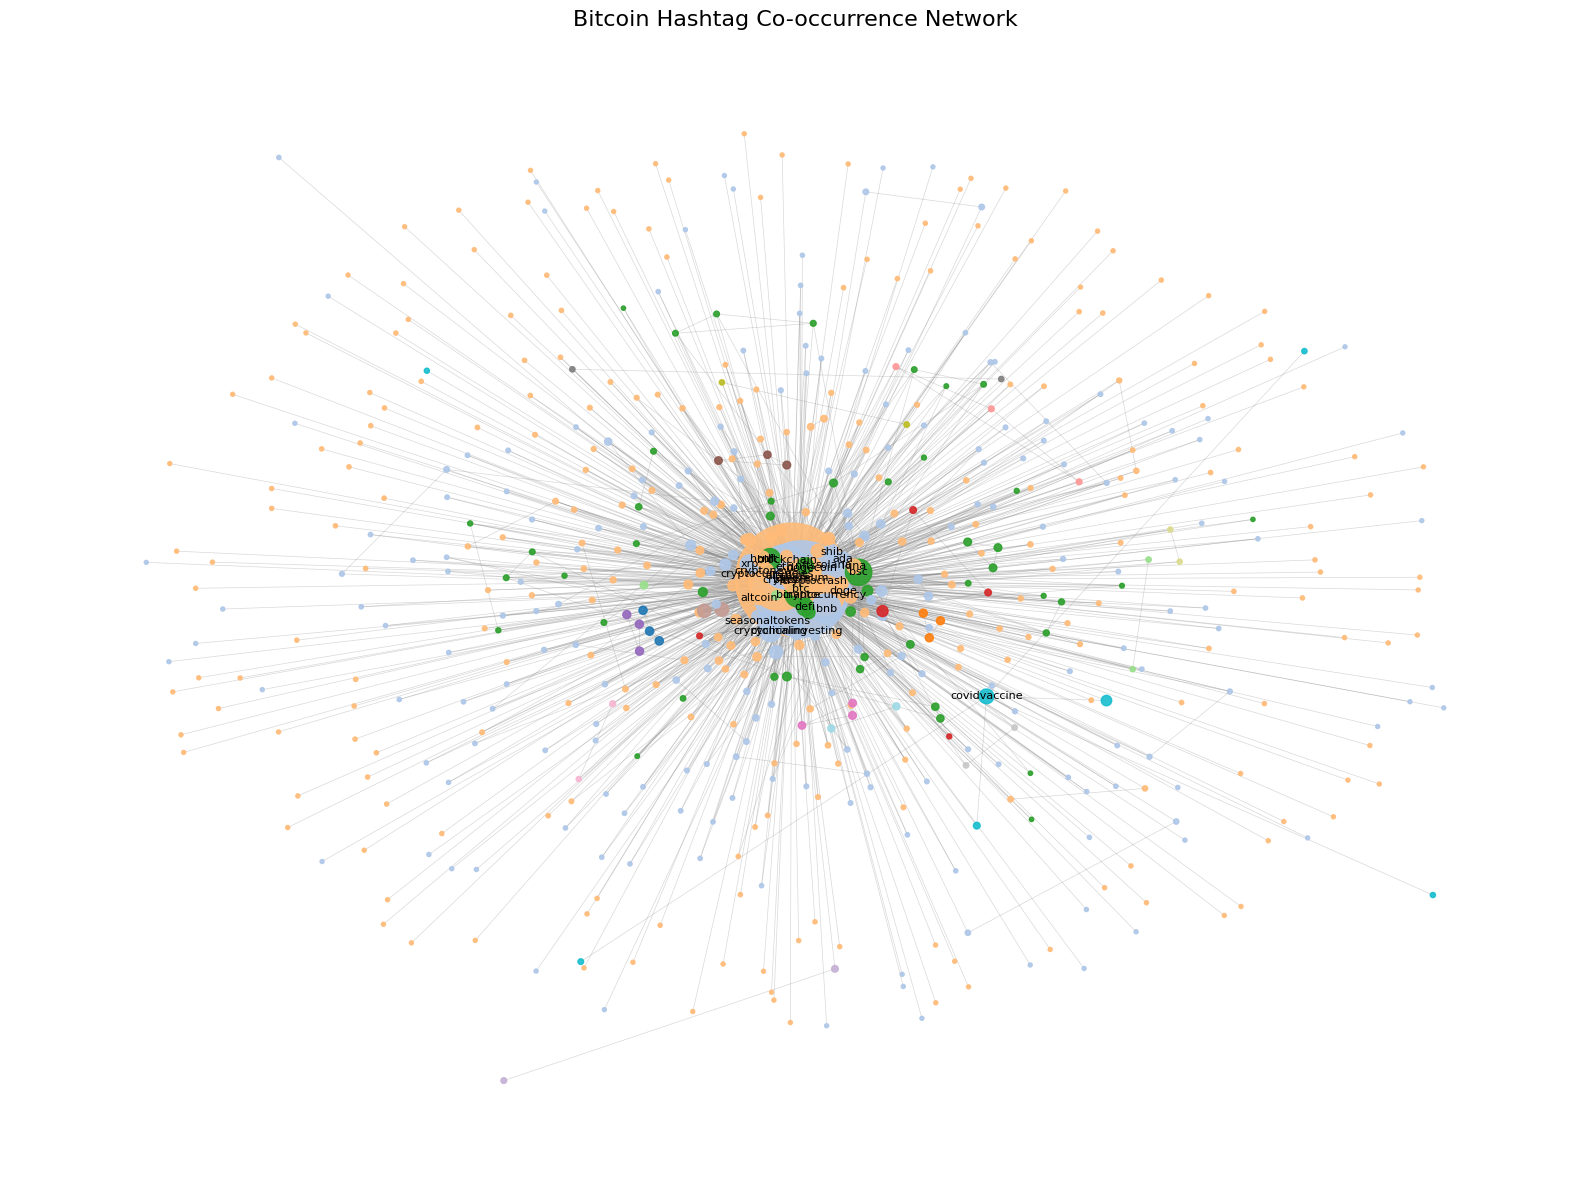

In [76]:
import matplotlib.cm as cm

plt.figure(figsize=(16, 12))

# Layout
pos = nx.spring_layout(G_main, weight='weight', seed=42, k=2)

# Colour by community
num_communities = len(set(partition.values()))
colours = cm.tab20(np.linspace(0, 1, num_communities))
node_colours = [colours[partition[node]] for node in G_main.nodes()]

# Size by pagerank
node_sizes = [pagerank[node] * 30000 for node in G_main.nodes()]

# Edge width by weight
edge_weights = [G_main[u][v]['weight'] for u, v in G_main.edges()]
max_w = max(edge_weights)
edge_widths = [0.5 + 3 * (w / max_w) for w in edge_weights]

nx.draw_networkx_edges(G_main, pos, width=edge_widths, alpha=0.3, edge_color='grey')
nx.draw_networkx_nodes(G_main, pos, node_color=node_colours, node_size=node_sizes, alpha=0.9)

# Label only the top nodes so it doesn't get cluttered
top_nodes = centrality_df.head(30)['hashtag'].tolist()
labels = {n: n for n in G_main.nodes() if n in top_nodes}
nx.draw_networkx_labels(G_main, pos, labels, font_size=8)

plt.title('Bitcoin Hashtag Co-occurrence Network', fontsize=16)
plt.axis('off')
plt.tight_layout()
#plt.savefig('network.png', dpi=150, bbox_inches='tight')
plt.show()

# mention network

In [77]:
# Remove tweets that are clearly coordinated mention spam
# Signal: many mentions + very few followers + mentions contain exchange/project names

EXCHANGE_ACCOUNTS = [
    'mexc_fans', 'mexc_updates', 'mexcresearch', 'binance', 
    'kucoin', 'bybit_official', 'coinbase', 'okx'
]

def is_mention_spam(row):
    mentions = row['mentions']
    if isinstance(mentions, str):
        import ast
        try:
            mentions = ast.literal_eval(mentions)
        except:
            return False
    
    if not isinstance(mentions, list):
        return False
        
    # Flag if mentions contain known exchange accounts
    has_exchange = any(m.lower() in EXCHANGE_ACCOUNTS for m in mentions)
    
    # Flag if too many mentions from low follower account
    too_many_mentions = len(mentions) >= 4 and row['user_followers'] < 100
    
    return has_exchange or too_many_mentions

df_mention = df[~df.apply(is_mention_spam, axis=1)]
df_mention

,user_name,user_created,user_followers,user_friends,user_verified,date,text,hashtags,mentions,account_age_days,age_bucket,url_count,text_clean,hashtag_list
16,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,[BTC],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,3-5 yr,0,- 39000$ This is so amazing. I am impressed wi...,[btc]
24,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,[BTC],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,>10 yr,0,Not now as there is fud of sub $30k ...people ...,[btc]
25,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,[BTC],[],1161,3-5 yr,0,I personally ignore weekend moves and chill wi...,[btc]
31,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,"[Bitcoin, BTC]",[],1287,3-5 yr,0,Move Digital Energy Through Cyber Space.,"[bitcoin, btc]"
51,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...","[cronje, frognation, BTC]",[],1812,3-5 yr,0,"1/2 End of shitcoin season, lasted even longer...","[cronje, frognation, btc]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595407,COLDSPACE,2021-07-16 23:03:54+00:00,32,403,False,2026-03-02 23:59:27+00:00,@MartiniGuyYT All you need is an internet conn...,"[fiat, Bitcoin, Cryptos, censorship, Resistance]",[martiniguyyt],1328,3-5 yr,0,All you need is an internet connection and a w...,"[fiat, bitcoin, cryptos, censorship, resistance]"
4595411,Crypto Geek,2022-02-28 23:34:18+00:00,4,23,False,2026-03-02 23:59:31+00:00,@lexfridman @saylor 1. How can #Bitcoin become...,"[Bitcoin, Crypto]","[lexfridman, saylor]",1101,3-5 yr,0,1. How can become a global currency for every ...,"[bitcoin, crypto]"
4595422,Hodlers Journey 🍁 ⚡️,2021-04-08 18:39:21+00:00,236,1126,False,2026-03-02 23:59:49+00:00,@jkenney Now eliminate the debt and add #bitco...,[bitcoin],[jkenney],1427,3-5 yr,0,Now eliminate the debt and add to the Provinci...,[bitcoin]
4595425,Blessed Mom of 3 kiddos~I 💗 them so much~🕊️🥀,2011-06-07 14:40:15+00:00,336,878,False,2026-03-02 23:59:52+00:00,@TheMoonCarl #Solana #MATIC maybe #Ada but if ...,"[Solana, MATIC, Ada, Bitcoin]",[themooncarl],5020,>10 yr,0,maybe but if probably put it into,"[solana, matic, ada, bitcoin]"


### Build mention edge list

In [78]:
df_mention = df_mention[["user_name", "mentions"]]

df_mentions_exploded = df_mention.explode("mentions")

# Drop rows where a user had no mentions
df_exploded = df_mentions_exploded.dropna(subset=["mentions"])
df_exploded


,user_name,mentions
16,Alal,mexcresearch
16,Alal,mexc_fans
16,Alal,mexc_updates
16,Alal,alnahyanprince1
16,Alal,apnahyan2
...,...,...
4595407,COLDSPACE,martiniguyyt
4595411,Crypto Geek,lexfridman
4595411,Crypto Geek,saylor
4595422,Hodlers Journey 🍁 ⚡️,jkenney


In [ ]:
# Normalise casing and drop self-mentions
df_exploded = df_exploded.copy()
df_exploded["user_name"] = df_exploded["user_name"].str.lower().str.strip()
df_exploded["mentions"]  = df_exploded["mentions"].str.lower().str.strip()
df_exploded = df_exploded[df_exploded["user_name"] != df_exploded["mentions"]]

# Count how many times each (user -> mentioned_user) pair appears
df_mentions_exploded = (
    df_exploded
    .groupby(["user_name", "mentions"], sort=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(f"Unique mention pairs: {len(df_mentions_exploded):,}")
df_mentions_exploded.head()


Unique mention pairs: 416,413


,user_name,mentions,count
291076,hamidreza,binance,186
291074,hamidreza,fegtoken,179
290917,abbas khoda,binance,164
290915,abbas khoda,fegtoken,140
290968,ali,binance,136


In [80]:
G_mention = nx.from_pandas_edgelist(
    df_mentions_exploded,
    source="user_name",
    target="mentions",
    edge_attr="count",
    create_using=nx.DiGraph()
)

print(f"Nodes: {G_mention.number_of_nodes():,}")
print(f"Edges: {G_mention.number_of_edges():,}")


Nodes: 220,026
Edges: 416,413


In [81]:
# Top mentioned users by total incoming mention weight
df_mentions_exploded.groupby("mentions")["count"].sum().sort_values(ascending=False).head(10)


mentions
elonmusk           11821
saylor              9472
peterschiff         7564
cz_binance          4817
bitcoinmagazine     4743
btc_archive         4531
themooncarl         4240
binance             3752
jack                3562
apompliano          3457
Name: count, dtype: int64

In [82]:
df_mentions_exploded

,user_name,mentions,count
291076,hamidreza,binance,186
291074,hamidreza,fegtoken,179
290917,abbas khoda,binance,164
290915,abbas khoda,fegtoken,140
290968,ali,binance,136
...,...,...,...
416408,coldspace,martiniguyyt,1
416409,crypto geek,lexfridman,1
416410,crypto geek,saylor,1
416411,hodlers journey 🍁 ⚡️,jkenney,1


In [83]:
G = nx.from_pandas_edgelist(
    df_mentions_exploded,
    source='user_name',
    target='mentions',
    edge_attr='count',
    create_using=nx.Graph()
)


Visualizing a clean network of 1167 nodes.


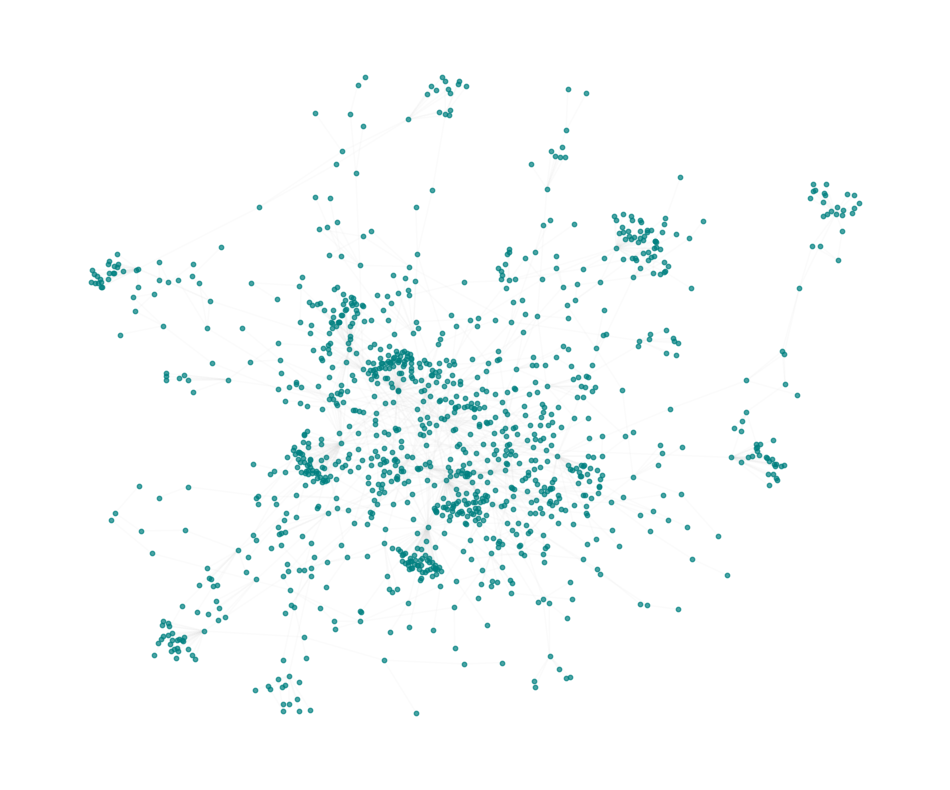

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx


df_heavy = df_mentions_exploded[df_mentions_exploded['count'] > 5]

G_light = nx.from_pandas_edgelist(df_heavy, 'user_name', 'mentions', edge_attr='count')

giant = max(nx.connected_components(G_light), key=len)
G_final = G_light.subgraph(giant).copy()

print(f"Visualizing a network of {G_final.number_of_nodes()} nodes")

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_final, k=0.15, seed=42) 

nx.draw_networkx_edges(G_final, pos, alpha=0.1, edge_color='gainsboro')
nx.draw_networkx_nodes(G_final, pos, node_size=10, node_color='teal', alpha=0.7)

plt.axis('off')
plt.show()

In [85]:
#nx.draw_kamada_kawai(G)

In [86]:
# In-degree = how much you get mentioned = influence proxy
in_degree = dict(G_mention.in_degree(weight='weight'))
top_mentioned = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:20]
print("Most mentioned users:")
for user, count in top_mentioned:
    print(f"  @{user}: {count} mentions")

Most mentioned users:
  @elonmusk: 8640 mentions
  @saylor: 6902 mentions
  @peterschiff: 5188 mentions
  @bitcoinmagazine: 3660 mentions
  @btc_archive: 3544 mentions
  @cz_binance: 3302 mentions
  @themooncarl: 3116 mentions
  @jack: 2831 mentions
  @apompliano: 2821 mentions
  @michael_saylor: 2409 mentions
  @rovercrc: 2355 mentions
  @binance: 2332 mentions
  @thecryptolark: 2111 mentions
  @nayibbukele: 1745 mentions
  @watcherguru: 1739 mentions
  @altcoindailyio: 1605 mentions
  @betfury: 1525 mentions
  @mmcrypto: 1474 mentions
  @maxkeiser: 1463 mentions
  @intocryptoverse: 1435 mentions
